<a href="https://colab.research.google.com/github/MalgosiaKacp/lecture1/blob/main/pum5_regresjanieliniowa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import PredictionErrorDisplay

In [110]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Salary Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rkiattisak/salaly-prediction-for-beginer",
  file_path,
)

print("First 5 records:", df.head())

/tmp/ipykernel_1734/2150386848.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'salaly-prediction-for-beginer' dataset.
First 5 records:     Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [111]:
df.info()

le = LabelEncoder()

for column in ['Gender', 'Education Level', 'Job Title']:
  if column in df.columns:
    df[column] = le.fit_transform(df[column])

print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB
    Age  Gender  Education Level  Job Title  Years of Experience    Salary
0  32.0       1                0        159                  5.0   90000.0
1  28.0       0                1         17                  3.0   65000.0
2  45.0       1                2        130                 15.0  150000.0
3  36.0       0                0        101                  7.0   60000.0
4  52.0       1                1         22                 20.0  20

In [112]:
df.dropna(inplace=True)
y = df['Salary']
X = df.drop('Salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Zbuduj model benchmarkowy - zwykłą regresję liniową

In [113]:
regressor = LinearRegression().fit(X_train, y_train)
print(f"Współczynniki: {regressor.coef_}")
print(f"Wyraz wolny: {regressor.intercept_}")
print(f" R^2 {regressor.score(X_train, y_train)}")
print(f"Średni błąd absolutny z treningu: {mean_absolute_error(y_train, regressor.predict(X_train)):.2f}")

y_pred = regressor.predict(X_test)
print(f"Średni błąd kwadratowy: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Średni błąd absolutny: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Wyjaśniona wariancja: {explained_variance_score(y_test, y_pred):.2f}")

Współczynniki: [ 3400.65625     7384.17507075 15289.75305615    38.30848175
  2155.12465162]
Wyraz wolny: -63972.08387966572
 R^2 0.9043289032978942
Średni błąd absolutny z treningu: 11171.01
Średni błąd kwadratowy: 252493731.92
Średni błąd absolutny: 11377.18
Wyjaśniona wariancja: 0.89


Sprawdź czy w danych występuje współliniowość współczynnikiem VIF

In [114]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# calculating VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

               feature        VIF
0                  Age  15.191310
1               Gender   2.059767
2      Education Level   2.403316
3            Job Title   4.865563
4  Years of Experience   9.479247


In [115]:

X_without_age = X.drop('Age', axis=1)

vif_data_updated = pd.DataFrame()
vif_data_updated["feature"] = X_without_age.columns
vif_data_updated["VIF"] = [variance_inflation_factor(X_without_age.values, i) for i in range(len(X_without_age.columns))]
print("VIF values after dropping 'Age' column:")
print(vif_data_updated)

VIF values after dropping 'Age' column:
               feature       VIF
0               Gender  1.819647
1      Education Level  2.379329
2            Job Title  2.798903
3  Years of Experience  4.147387


Spróbuj poprawić wynik używając regresji LASSO

In [116]:
df.dropna(inplace=True)
y = df['Salary']
X = df.drop(['Salary', 'Age'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [117]:
from sklearn import linear_model
clf = linear_model.Lasso(alpha=0.1)
clf.fit(X_train, y_train)
y_pred_lasso = clf.predict(X_test)

print(f"Współczynniki: {clf.coef_}")
print(f"Wyraz wolny: {clf.intercept_}")
print(f"R^2 na zbiorze treningowym: {clf.score(X_train, y_train):.2f}")
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
print(f'MAE dla Lasso: {mae_lasso}')

Współczynniki: [ 5942.70318005 14230.37327155    45.79269997  5841.36914565]
Wyraz wolny: 27035.419733821444
R^2 na zbiorze treningowym: 0.89
MAE dla Lasso: 11005.930422155167


<Axes: xlabel='Years of Experience', ylabel='Salary'>

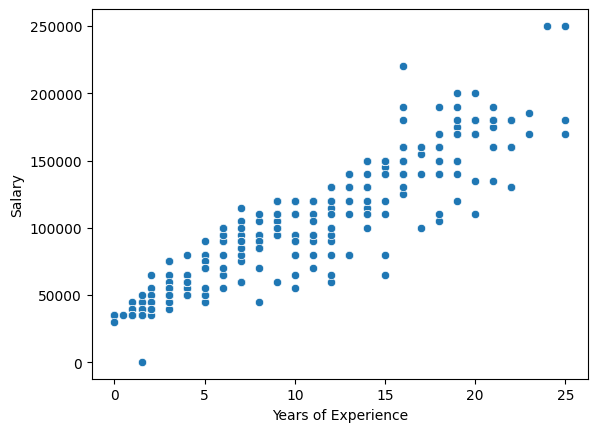

In [118]:
import seaborn as sns
sns.scatterplot(data=df, x="Years of Experience", y="Salary")

Zbuduj dodatkową zmienną, kwadrat lat doświadczenia, zbuduj ponownie regresję


In [119]:
df['years2'] = df['Years of Experience']**2

In [120]:
df.dropna(inplace=True)
y = df['Salary']
X = df.drop(['Salary', 'Age'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [121]:
# dla wielomianu stopnia 2
from sklearn import linear_model
clf = linear_model.Lasso(alpha=0.1)
clf.fit(X_train, y_train)
y_pred_lasso = clf.predict(X_test)

print(f"Współczynniki: {clf.coef_}")
print(f"Wyraz wolny: {clf.intercept_}")
print(f"R^2 na zbiorze treningowym: {clf.score(X_train, y_train):.2f}")
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
print(f'MAE dla Lasso: {mae_lasso}')

Współczynniki: [ 6564.74048628 14524.87650876    21.29936534  7172.65443893
   -59.32108658]
Wyraz wolny: 23893.867563841646
R^2 na zbiorze treningowym: 0.90
MAE dla Lasso: 10749.859202140373


narysyj wykres typu scatterplot, dla zmiennych lata doswiadczenia i płaca, czy regresja wyższego rzędu jest uzasadniona?

KNeighborsRegressor (k = 5, weights = 'uniform') R^2 score on test set: 0.86
MAE dla KNN: 11377.183126703107
KNeighborsRegressor (k = 5, weights = 'distance') R^2 score on test set: 0.86
MAE dla KNN: 11377.183126703107


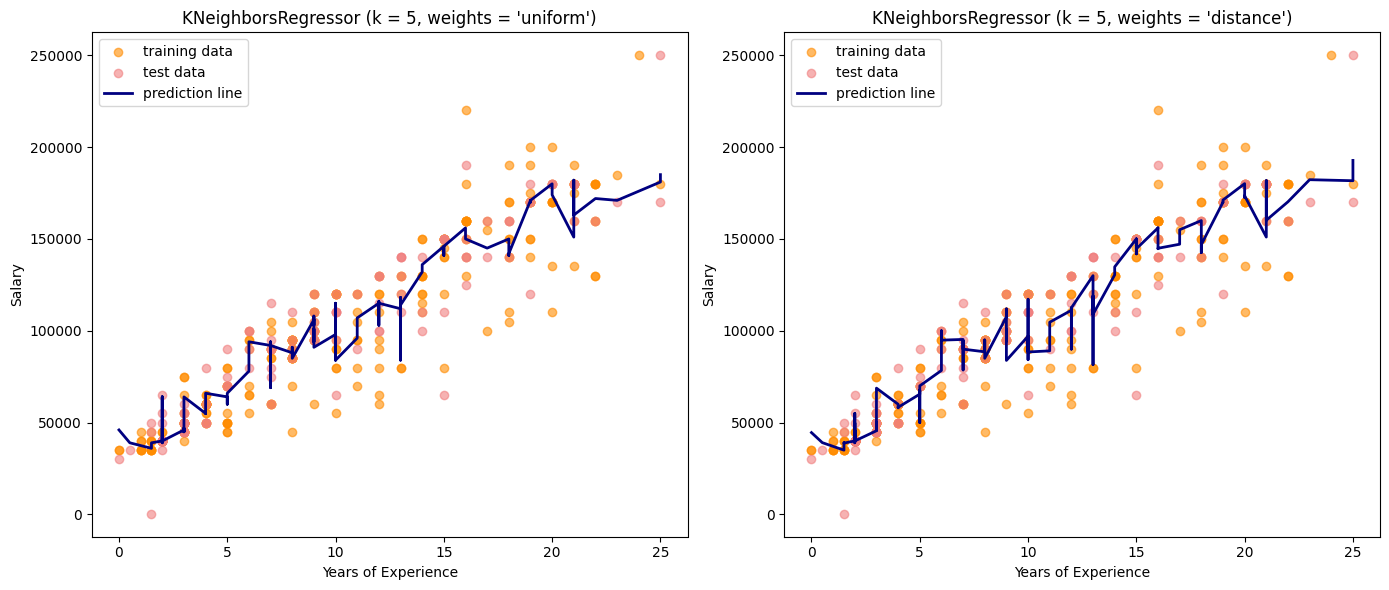

In [122]:
# dla wielomianu stopnia 2

from sklearn import neighbors
import matplotlib.pyplot as plt

n_neighbors = 5

plt.figure(figsize=(14, 6))

for i, weights_option in enumerate(['uniform', 'distance']):
    knn = neighbors.KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights_option)
    knn.fit(X_train, y_train)

    y_pred_test = knn.predict(X_test)

    r2_score_knn = knn.score(X_test, y_test)
    print(f"KNeighborsRegressor (k = {n_neighbors}, weights = '{weights_option}') R^2 score on test set: {r2_score_knn:.2f}")

    y_pred_knn = knn.predict(X_train)
    mae_knn = mean_absolute_error(y_test, y_pred)
    print(f'MAE dla KNN: {mae_knn}')

    X_test_sorted_idx = X_test['Years of Experience'].argsort()
    X_test_plot_sorted = X_test.iloc[X_test_sorted_idx]
    y_pred_test_sorted = y_pred_test[X_test_sorted_idx]

    plt.subplot(1, 2, i + 1)
    plt.scatter(X_train['Years of Experience'], y_train, color="darkorange", label="training data", alpha=0.6)
    plt.scatter(X_test['Years of Experience'], y_test, color="lightcoral", label="test data", alpha=0.6)
    plt.plot(X_test_plot_sorted['Years of Experience'], y_pred_test_sorted, color="navy", label="prediction line", linewidth=2)

    plt.xlabel("Years of Experience")
    plt.ylabel("Salary")
    plt.title(f"KNeighborsRegressor (k = {n_neighbors}, weights = '{weights_option}')")
    plt.legend()

plt.tight_layout()
plt.show()

Regresja wielomianowa stopnia 3

In [123]:
# dla wielomianu stopnia 3
df['years3'] = df['Years of Experience']**3

df.dropna(inplace=True)
y = df['Salary']
X = df.drop(['Salary', 'Age'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = linear_model.Lasso(alpha=0.1)
clf.fit(X_train, y_train)
y_pred_lasso = clf.predict(X_test)

print(f"Współczynniki: {clf.coef_}")
print(f"Wyraz wolny: {clf.intercept_}")
print(f"R^2 na zbiorze treningowym: {clf.score(X_train, y_train):.2f}")
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
print(f'MAE dla Lasso: {mae_lasso}')

Współczynniki: [ 6.53301632e+03  1.48026886e+04  2.26732765e+01  8.19992590e+03
 -1.74474596e+02  3.37367205e+00]
Wyraz wolny: 21774.918075072303
R^2 na zbiorze treningowym: 0.90
MAE dla Lasso: 10667.698052637146


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.176e+10, tolerance: 6.127e+07
  model = cd_fast.enet_coordinate_descent(


Spróbuj wykorzystać regresje za pomocą K-NN
https://scikit-learn.org/stable/auto_examples/neighbors/plot_regression.html#sphx-glr-auto-examples-neighbors-plot-regression-py

KNeighborsRegressor (k = 5, weights = 'uniform') R^2 score on test set: 0.86
MAE dla KNN: 11377.183126703107
KNeighborsRegressor (k = 5, weights = 'distance') R^2 score on test set: 0.86
MAE dla KNN: 11377.183126703107


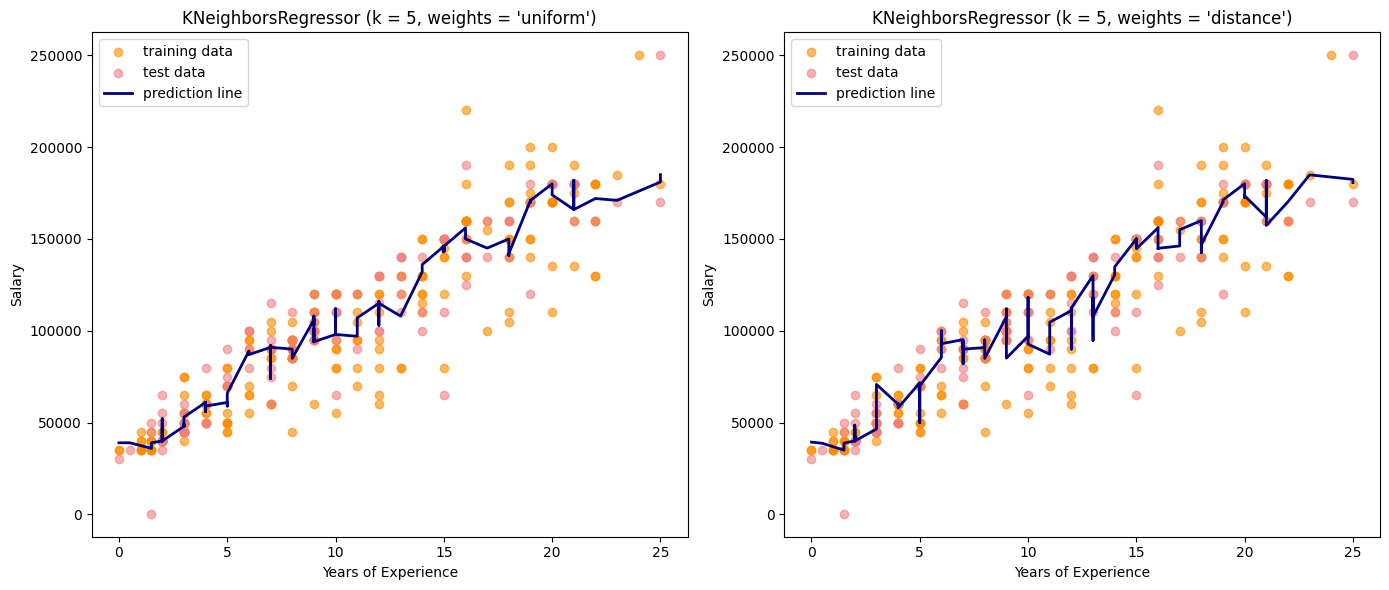

In [125]:
# dla wielomianu stopnia 3

n_neighbors = 5

plt.figure(figsize=(14, 6))

for i, weights_option in enumerate(['uniform', 'distance']):
    knn = neighbors.KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights_option)
    knn.fit(X_train, y_train)

    y_pred_test = knn.predict(X_test)

    r2_score_knn = knn.score(X_test, y_test)
    print(f"KNeighborsRegressor (k = {n_neighbors}, weights = '{weights_option}') R^2 score on test set: {r2_score_knn:.2f}")

    y_pred_knn = knn.predict(X_train)
    mae_knn = mean_absolute_error(y_test, y_pred)
    print(f'MAE dla KNN: {mae_knn}')

    X_test_sorted_idx = X_test['Years of Experience'].argsort()
    X_test_plot_sorted = X_test.iloc[X_test_sorted_idx]
    y_pred_test_sorted = y_pred_test[X_test_sorted_idx]

    plt.subplot(1, 2, i + 1)
    plt.scatter(X_train['Years of Experience'], y_train, color="darkorange", label="training data", alpha=0.6)
    plt.scatter(X_test['Years of Experience'], y_test, color="lightcoral", label="test data", alpha=0.6)
    plt.plot(X_test_plot_sorted['Years of Experience'], y_pred_test_sorted, color="navy", label="prediction line", linewidth=2)

    plt.xlabel("Years of Experience")
    plt.ylabel("Salary")
    plt.title(f"KNeighborsRegressor (k = {n_neighbors}, weights = '{weights_option}')")
    plt.legend()

plt.tight_layout()
plt.show()

WYNIKI:

* Regresja LASSO dla wielomianu stopnia 1: R^2 = 0.89, wyraz wolny = 27035.4, MAE = 11005.9
* Regresja LASSO dla wielomianu stopnia 2: R^2 = 0.90, wyraz wolny = 23893.9, MAE = 10749.9

* Regresja LASSO dla wielomianu stopnia 3: R^2 = 0.90, wyraz wolny = 21774.9, MAE = 10667.7


Metoda knn:
* Metoda knn dla wielomianu stopnia 2: R^2 = 0.86 dla obu uniform i distance, MAE = 11377.1
* Metoda knn dla wielomianu stopnia 3: R^2 = 0.86 dla obu uniform i distance, MAE = 11377.1

Regresja LASSO charakteryzuje się nieznacznie lepszym dopasowaniem niź metoda knn. Regresja wielomianowa 3 stopnia ma wyższe dopasowanie. Regresja LASSO ma mniejsze średnie błędy absolutne.

